# Classifier Analysis

This notebook is cleaned into clear stages: setup, checkpoint/data loading, representation probing, classification evaluation, baseline comparison, and interpretability.

## 1) Setup

In [8]:
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent):
        if (candidate / 'src').exists():
            return candidate
    raise FileNotFoundError("Cannot find project root containing 'src' directory.")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.preparation import prepare_data
from src.models.builders import ModelBuilder
from src.train.config_setup import load_args_from_checkpoint, load_model_from_checkpoint
from src.utils.mask_utils import get_non_pad_mask
from src.utils.metrics import classification_metrics
from src.utils.utils import _to_np_datetime64_seconds, set_seed
import src.data.event_loader as loader
import src.utils.analysis as analysis
import src.utils.interpretability as interp

set_seed(0)
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
FIG_DIR = PROJECT_ROOT / 'notebooks' / 'figs'
FIG_BATCH_DIR = FIG_DIR / 'clf'
FIG_DIR.mkdir(parents=True, exist_ok=True)
FIG_BATCH_DIR.mkdir(parents=True, exist_ok=True)

data_start = [1970, 1, 1, 0, 0, 0]
t0_np = _to_np_datetime64_seconds(datetime(*data_start))

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DEVICE: {DEVICE}')

PROJECT_ROOT: /root/autodl-tmp/chuandian_eq
DEVICE: cuda:0


## 2) Load Checkpoint and Data

In [9]:
CHECKPOINT_DIR = PROJECT_ROOT / 'checkpoints' / 'clf_mixer_attnpl_t_20260205-213430'
CHECKPOINT_PATH = CHECKPOINT_DIR / 'best_model_1.pth'
USE_TORCH_COMPILE = False
BATCH_SIZE = 32


def load_model_and_args(checkpoint_path: Path, device: torch.device, use_compile: bool = False):
    check_point = torch.load(checkpoint_path, map_location=device, weights_only=False)
    args = load_args_from_checkpoint(None, check_point)

    model_builder = ModelBuilder.by_name(args.model.lower())()
    model = model_builder(args, device)
    model, _, _ = load_model_from_checkpoint(model, check_point)

    if use_compile and hasattr(torch, 'compile'):
        model = torch.compile(model)

    model.eval()
    return model, args


model, args = load_model_and_args(CHECKPOINT_PATH, DEVICE, use_compile=USE_TORCH_COMPILE)
args.use_sampler = False
args.batch_size = BATCH_SIZE

base_dir = PROJECT_ROOT / 'data' / args.dataset
df, train_loader, val_loader, test_loader, catalog_ds = prepare_data(base_dir=str(base_dir), args=args)
data_loader = loader.get_dataloader(
    catalog_ds,
    batch_size=args.batch_size,
    shuffle=False,
    task_type=args.task_type,
)

print(f'Loaded checkpoint: {CHECKPOINT_PATH}')
print(f'Dataset: {args.dataset}')

Initializing MixerAdapter with stats: {'tau_unfiltered': 0.15339908988298961, 'tau_q025': 0.08114294020924717, 'tau_q05': 0.5134664350189269, 'tau_mean': 1.3070542199341526, 'tau_max': 25.18216435192153, 'tau_min': 0.0, 'time_max': 18770.72654999979, 'time_mean': 10030.9430649837, 'mag_completeness': 3.0, 'mag_mean': 3.456916005014626, 'mag_max': 8.0, 'mag_min': 3.0, 'b_value': 0.856738547623331, 'b_std': 0.0071499224812533796, 'b_n': 14358}
using extractor: attn_time_biased_mh time_bias_type: log extractor_config: {}
load_specific_parts: None
Checkpoint loaded: <All keys matched successfully>
hyperparameters: {'resume_path': './checkpoints/mixer_tpp_20260203-161948/last_model_1.pth', 'load_specific_parts': ['encoder'], 'model': 'clf_mixer_attnpl_t', 'use_ema': False, 'batch_size': 64, 'accumulation_steps': 1, 'warmup_ratio': 0.1, 'learning_rate': 0.0006, 'weight_decay': 0.001, 'scheduler_factor': None, 'scheduler_patience': None, 'scheduler_threshold': None, 'scheduler_min_lr': 1e-06,

## 3) Representation Probe

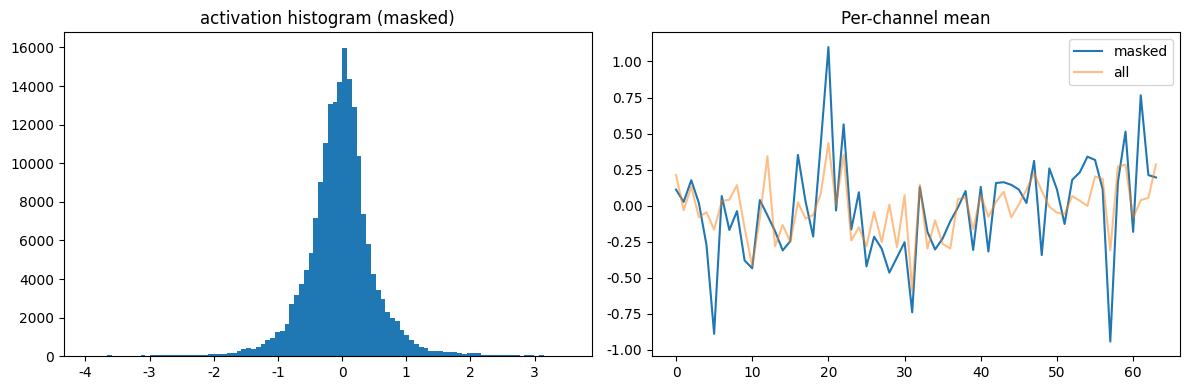

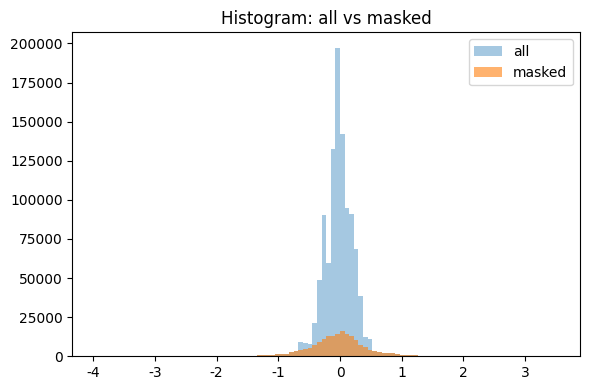

In [10]:
x_batch, y_batch = next(iter(data_loader))
x_batch = x_batch.to(DEVICE)
y_batch = y_batch.to(DEVICE)

valid_mask = get_non_pad_mask(x_batch[:, :, 0]).squeeze(-1).cpu().bool()
_activations = interp.capture_layer_activations(
    model,
    x_batch,
    module=model.base_model.encoder.layers[0],
    valid_mask=valid_mask,
    visualize=True,
)

## 4) Model Metrics and t-SNE by Split

=== TRAIN: classification_metrics ===
{'precision': 0.7293972939729397, 'recall': 0.839943342776204, 'f1': 0.7807768268597761, 'auc': 0.8135550467616128, 'pr_auc': 0.9001415320217482, 'fpr': 0.502283105022831, 'tpr': 0.839943342776204, 'R': 0.33766023775337295, 'conf': 1.0, 'threshold': 0.3550296425819397}


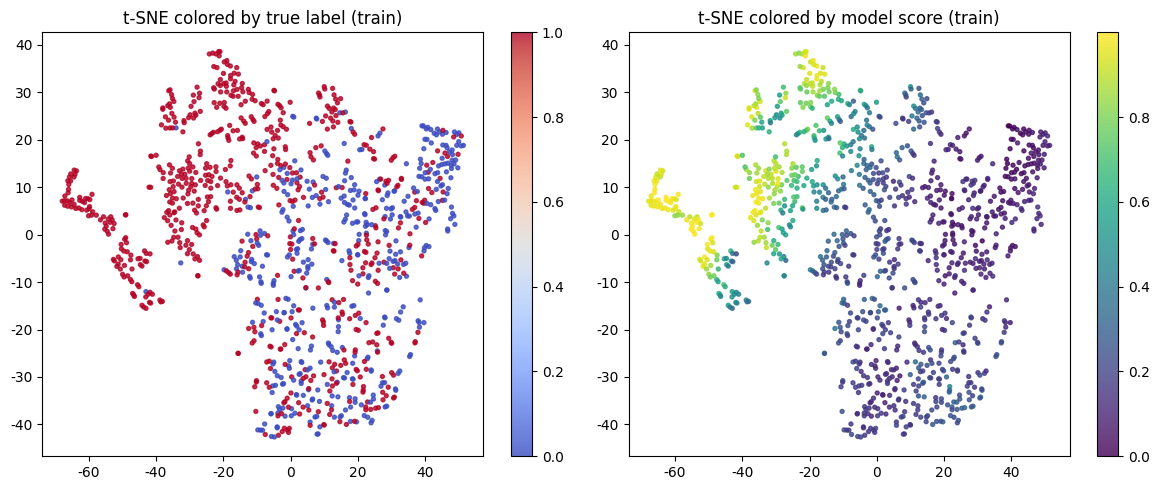

=== VAL: classification_metrics ===
{'precision': 0.6377952755905512, 'recall': 0.9759036144578314, 'f1': 0.7714285714285715, 'auc': 0.7600401606425703, 'pr_auc': 0.8371695266694815, 'fpr': 0.7666666666666667, 'tpr': 0.9759036144578314, 'R': 0.20923694779116464, 'conf': 0.0019910004391618425, 'threshold': 0.2959364354610443}


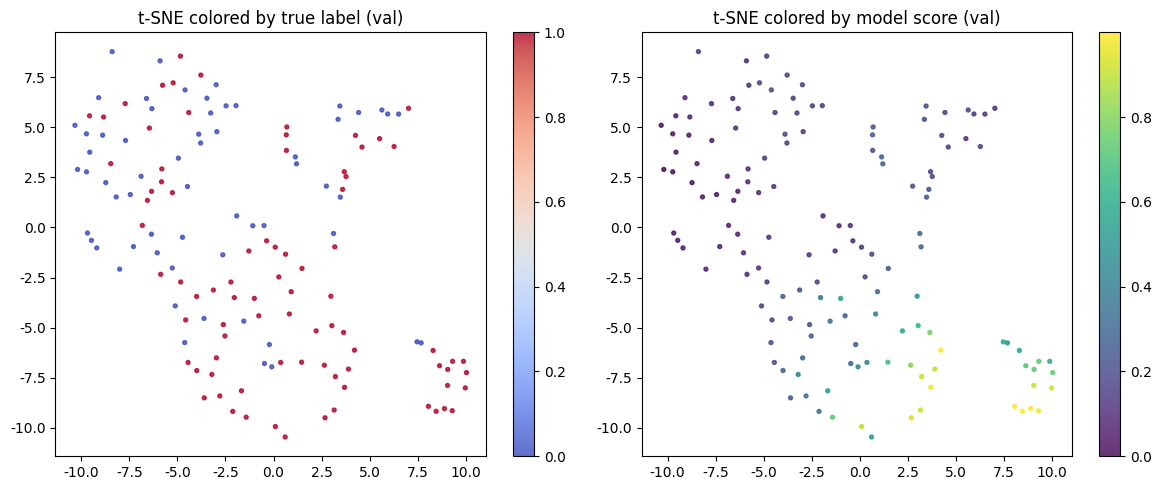

=== TEST: classification_metrics ===
{'precision': 0.9090909090909091, 'recall': 0.6382978723404256, 'f1': 0.75, 'auc': 0.8993794326241135, 'pr_auc': 0.8516222215159499, 'fpr': 0.03125, 'tpr': 0.6382978723404256, 'R': 0.6070478723404256, 'conf': 1.0, 'threshold': 0.4732005000114441}


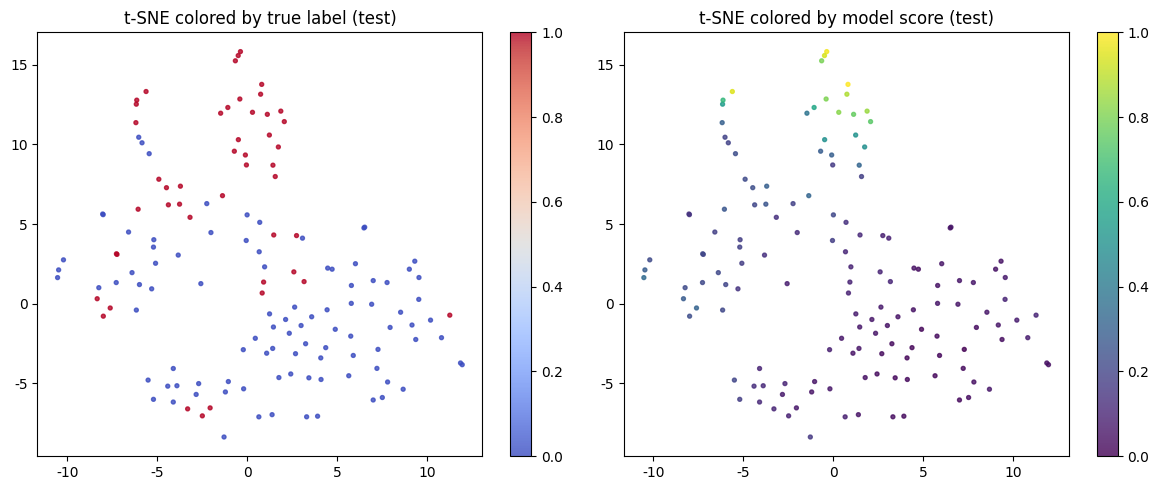

In [11]:
split_outputs = {
    'train': analysis.predict_all(model, train_loader, DEVICE, return_X=True),
    'val': analysis.predict_all(model, val_loader, DEVICE, return_X=True),
    'test': analysis.predict_all(model, test_loader, DEVICE, return_X=True),
}


def run_metrics_and_tsne(split_outputs: dict, splits=('val',), do_tsne: bool = True):
    for split in splits:
        if split not in split_outputs:
            print(f'[Skip] Unknown split: {split}')
            continue

        y_pred, y_true, x_feat = split_outputs[split]

        print(f'=== {split.upper()}: classification_metrics ===')
        try:
            print(classification_metrics(y_true, y_pred))
        except Exception as exc:
            print(f'[Warn] classification_metrics({split}) failed: {exc}')

        if do_tsne:
            try:
                analysis.tsne_scatter(
                    x_feat.astype(float),
                    y_all=y_true,
                    y_pred_all=y_pred,
                    title_left=f't-SNE colored by true label ({split})',
                    title_right=f't-SNE colored by model score ({split})',
                )
            except Exception as exc:
                print(f'[Warn] t-SNE({split}) failed: {exc}')


selected_splits = ['train', 'val', 'test']
run_metrics_and_tsne(split_outputs, splits=selected_splits, do_tsne=True)

## 5) Random Forest Baseline on Learned Features

Accuracy: 0.7552447552447552
              precision    recall  f1-score   support

         0.0     0.8427    0.7812    0.8108        96
         1.0     0.6111    0.7021    0.6535        47

    accuracy                         0.7552       143
   macro avg     0.7269    0.7417    0.7321       143
weighted avg     0.7666    0.7552    0.7591       143

ROC AUC: 0.8305629432624113


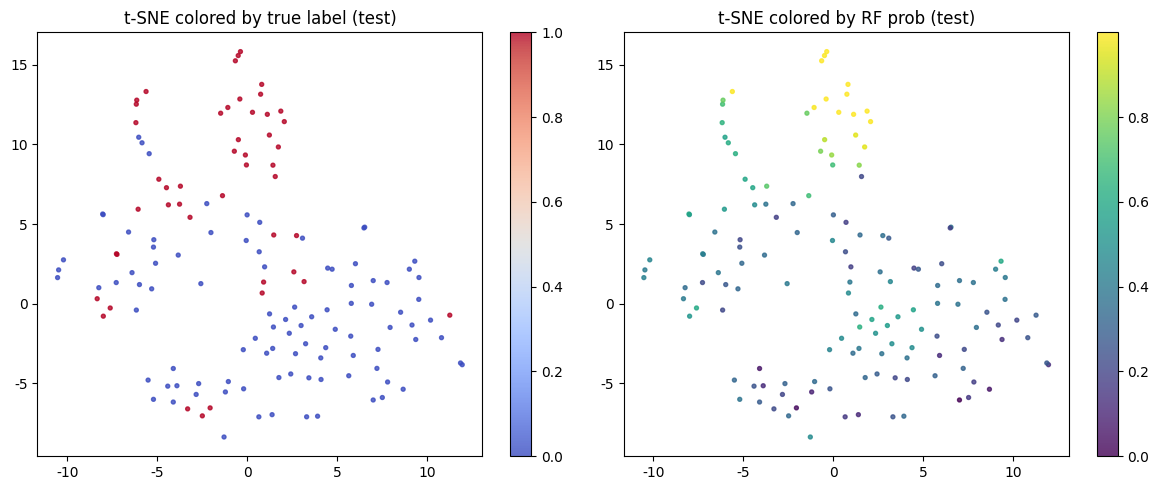

(array([[-1.10094344, -1.01868539,  0.86080322, ...,  0.24333954,
         -0.95675681, -0.51716645],
        [-0.5143803 , -0.86946899,  0.64583223, ...,  0.29446322,
         -0.28173226, -0.31113069],
        [ 0.66199804, -0.58927154, -0.7674708 , ...,  0.13163606,
          0.55034054, -0.00931083],
        ...,
        [ 0.2705814 , -0.1830248 ,  0.14909728, ...,  0.92348606,
         -0.54106381, -1.01976958],
        [ 0.91524404,  0.45291949, -1.21629381, ...,  0.27021829,
         -0.36535084, -0.92844565],
        [-1.05599988, -1.03917793,  1.29604767, ...,  1.08233249,
         -1.28140123, -1.33120894]]),
 array([[ 6.53449965e+00,  4.80485010e+00],
        [ 6.49154139e+00,  4.75720549e+00],
        [ 4.47796822e+00,  2.23276043e+00],
        [ 4.72353840e+00,  2.16425347e+00],
        [ 6.01967525e+00,  2.50958920e+00],
        [ 9.55008125e+00,  1.64218104e+00],
        [ 9.01469994e+00,  2.16492558e+00],
        [ 9.31725502e+00,  2.66775250e+00],
        [ 7.94598627e

In [12]:
y_pred_train, y_train, X_train = split_outputs['train']
y_pred_val, y_val, X_val = split_outputs['val']
y_pred_test, y_test, X_test = split_outputs['test']

rf = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, digits=4))
print('ROC AUC:', roc_auc_score(y_test, y_proba_rf))

analysis.tsne_scatter(
    X_test,
    y_all=y_test,
    y_pred_all=y_proba_rf,
    title_left='t-SNE colored by true label (test)',
    title_right='t-SNE colored by RF prob (test)',
)

## 6) Interpretability (Integrated Gradients)

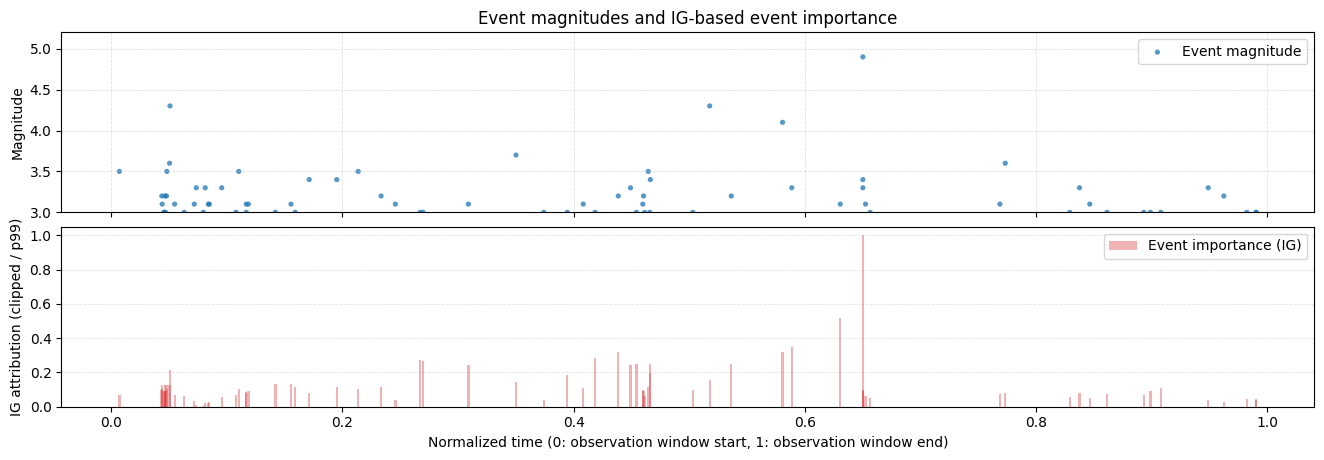

observation window: 1970-07-25 07:23:48+00:00 to 1971-01-18 07:54:55+00:00 (duration: 177 days, 0:31:07)


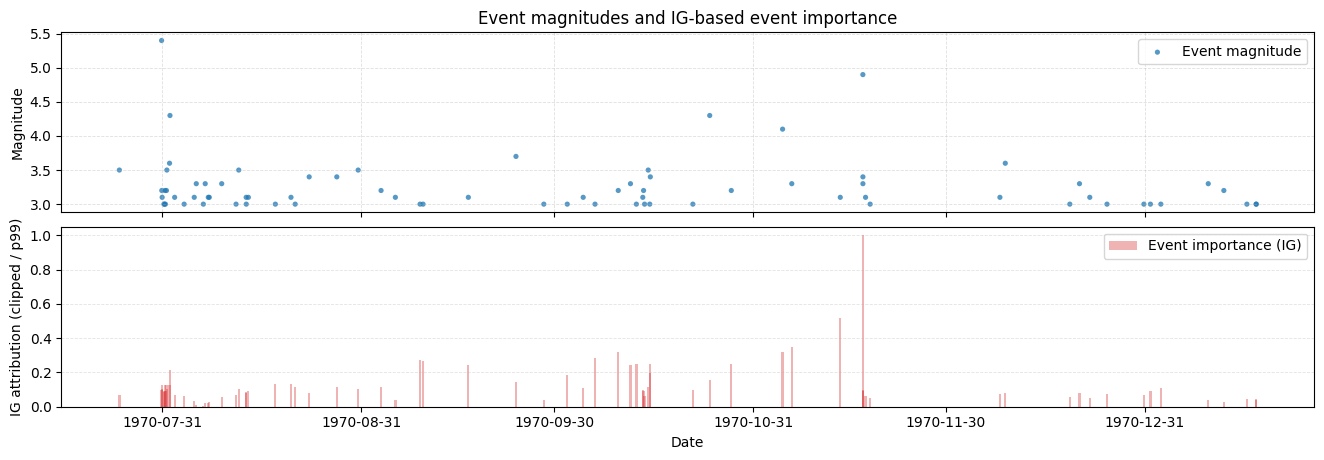

(<Figure size 1400x480 with 2 Axes>,
 <Axes: title={'center': 'Event magnitudes and IG-based event importance'}, ylabel='Magnitude'>,
 <Axes: xlabel='Date', ylabel='IG attribution (clipped / p99)'>)

In [13]:
IG_STEPS = 300
SAMPLE_IDX = 14

x_ig = next(iter(data_loader))[0].to(DEVICE)
scores, labels = interp.compute_token_importance(
    model,
    x_ig,
    method='ig',
    n_steps=IG_STEPS,
    signed=False,
)

mask_np = get_non_pad_mask(x_ig[:, :, 0]).squeeze(-1).cpu().numpy().astype(bool)

interp.plot_event_magnitude_and_importance_clean(
    x_ig,
    scores,
    batch_idx=SAMPLE_IDX,
    time_channel=1,
    mag_channel=2,
    importance_norm='p99',
    savepath=str(FIG_DIR / 'clf_interp_nl.pdf'),
    mag_color='tab:blue',
    imp_color='tab:red',
    mask=mask_np,
    height_ratios=(2, 2),
)

interp.plot_event_magnitude_and_importance_clean(
    x_ig,
    scores,
    batch_idx=SAMPLE_IDX,
    time_channel=0,
    x_axis='time',
    start_time=t0_np,
    time_scale=1.0,
    time_unit='D',
    mag_channel=2,
    importance_norm='p99',
    savepath=str(FIG_DIR / 'clf_interp.pdf'),
    mag_color='tab:blue',
    imp_color='tab:red',
    mask=mask_np,
    height_ratios=(2, 2),
    xlabel='Date',
    clip_mag =None,
)

observation window: 1974-01-09 19:29:49+00:00 to 1974-07-01 09:48:31+00:00 (duration: 172 days, 14:18:42)


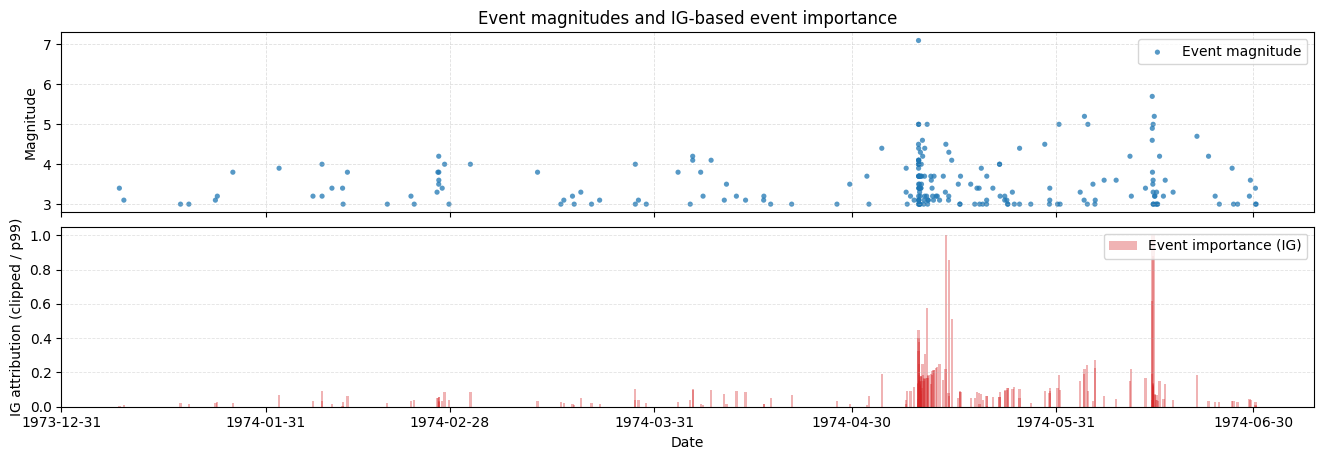

observation window: 1985-02-06 09:34:27+00:00 to 1985-08-01 23:07:16+00:00 (duration: 176 days, 13:32:49)


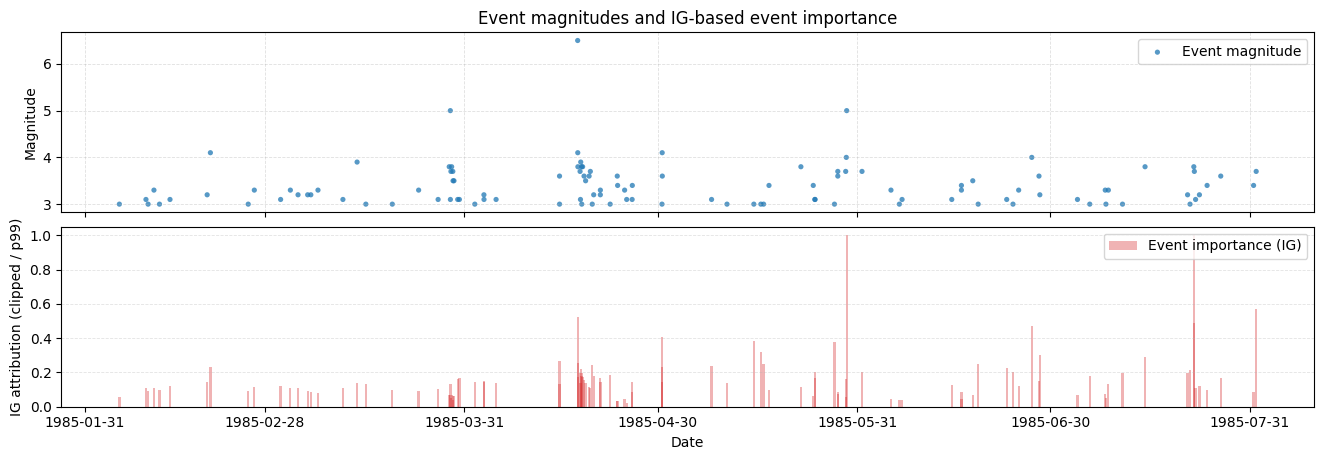

observation window: 1997-08-02 03:05:38+00:00 to 1998-01-20 22:01:52+00:00 (duration: 171 days, 18:56:14)


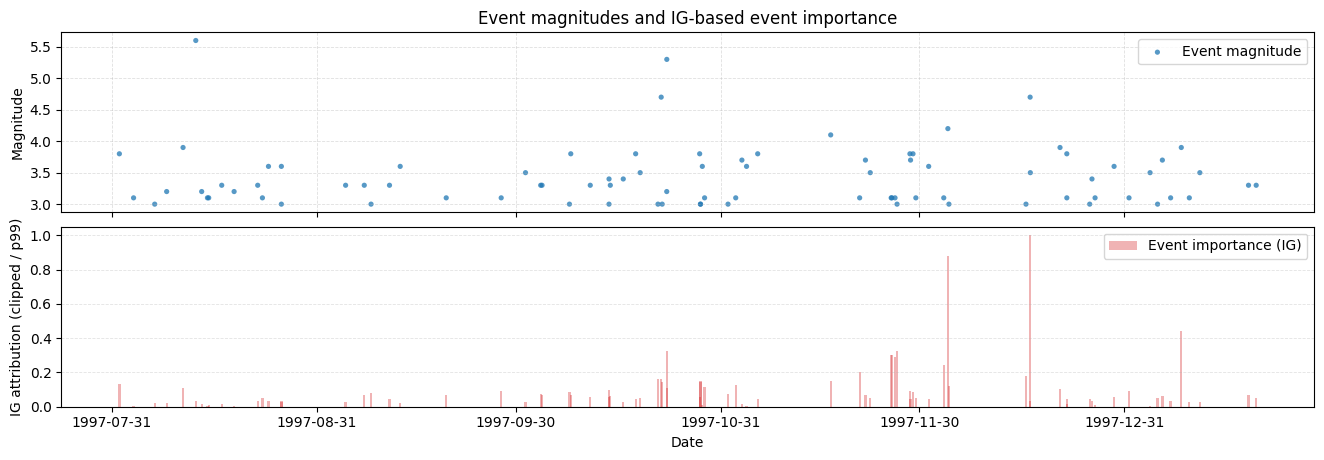

observation window: 2007-12-18 08:16:24+00:00 to 2008-06-11 13:00:28+00:00 (duration: 176 days, 4:44:04)


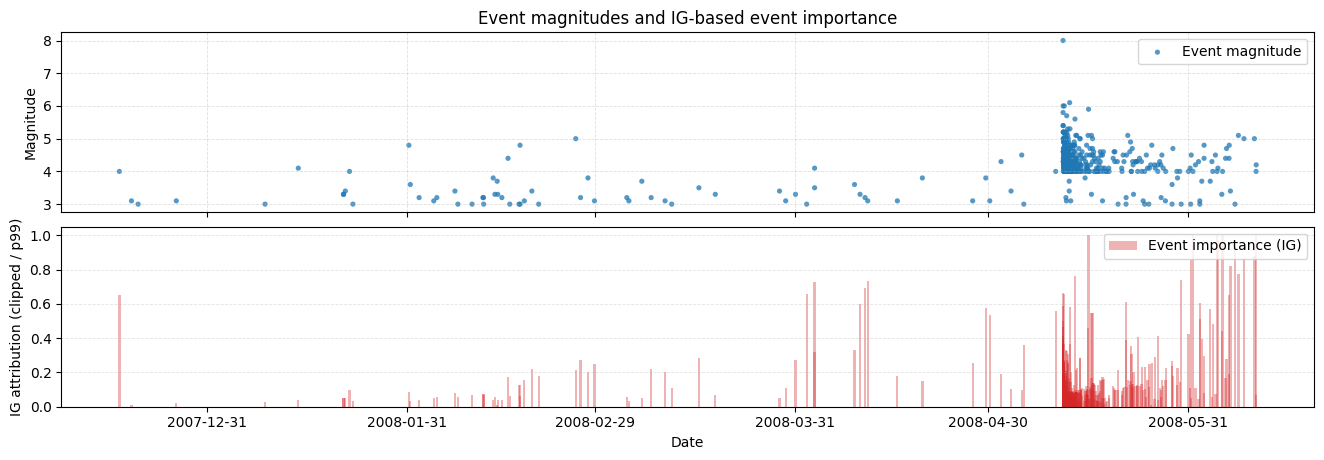

observation window: 2019-03-09 02:37:30+00:00 to 2019-09-03 03:02:49+00:00 (duration: 178 days, 0:25:19)


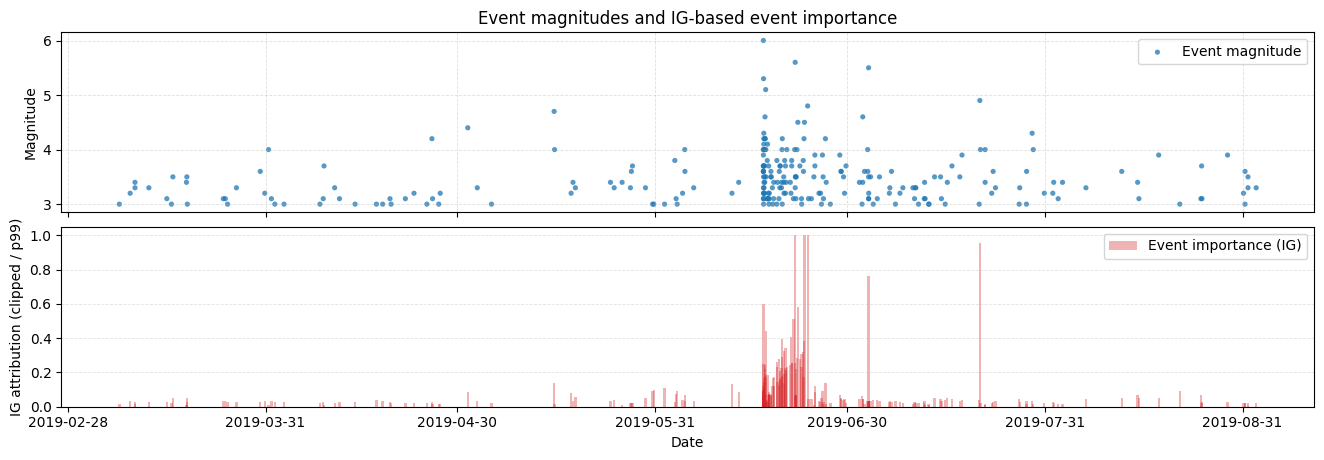

In [16]:
def batch_export_interpretability(
    model,
    data_loader,
    out_dir: Path,
    start_time,
    every_n: int = 10,
    match_mod: int = 3,
    ig_steps: int = 200,
):
    out_dir.mkdir(parents=True, exist_ok=True)

    for batch_id, (x_batch, y_batch) in enumerate(data_loader):
        if batch_id % every_n != match_mod:
            continue

        sample_idx = np.random.randint(0, x_batch.shape[0])
        scores, _ = interp.compute_token_importance(
            model,
            x_batch,
            method='ig',
            n_steps=ig_steps,
            signed=False,
        )
        mask = get_non_pad_mask(x_batch[:, :, 0]).squeeze(-1).cpu().numpy().astype(bool)

        savepath = out_dir / f'clf_interp_{batch_id}_{sample_idx}.pdf'
        interp.plot_event_magnitude_and_importance_clean(
            x_batch,
            scores,
            batch_idx=sample_idx,
            time_channel=0,
            x_axis='time',
            start_time=start_time,
            time_scale=1.0,
            time_unit='D',
            mag_channel=2,
            importance_norm='p99',
            savepath=str(savepath),
            mag_color='tab:blue',
            imp_color='tab:red',
            mask=mask,
            height_ratios=(2, 2),
            xlabel='Date',
            clip_mag=None,
        )

set_seed(0)
batch_export_interpretability(
    model=model,
    data_loader=data_loader,
    out_dir=FIG_BATCH_DIR,
    start_time=t0_np,
    every_n=10,
    match_mod=3,
    ig_steps=200,
)